# SMD

# M1

# MODULE 1 — Compréhension des enjeux stratégiques

Ce module est théorique : aucune donnée ni code n'est utilisé. L'objectif est de poser
le cadre stratégique avant l'analyse technique (M2 à M9).

## 1. Pourquoi la personnalisation marketing ?

- **Efficacité** : un message ciblé convertit mieux qu'un message de masse.
- **Fidélisation** : comprendre les segments permet d'anticiper les besoins et de
  réduire le taux de désabonnement (churn).
- **Allocation budgétaire** : identifier le canal/segment le plus rentable évite de
  gaspiller le budget marketing.
- **Avantage concurrentiel** : l'IA permet de personnaliser à grande échelle, ce qui
  est impossible manuellement.

## 2. Analyse SWOT (contexte : marketing digital personnalisé, retail multi-canal)

|                | Positif                                                        | Négatif                                                          |
|----------------|-----------------------------------------------------------------|-------------------------------------------------------------------|
| **Interne**    | **Forces**                                                       | **Faiblesses**                                                     |
|                | Données clients, produits et ventes déjà collectées et structurées | Volume de données limité (échantillon réduit) pour entraîner des modèles robustes |
|                | Présence multi-canal (Online, In-Store, Social, Email, TV)      | Absence de données comportementales fines (pages vues, temps passé, etc.) |
|                | Diversité des catégories produits (Clothing, Footwear, Outerwear, Accessories) | Pas encore d'historique de churn ou de désabonnement enregistré |
| **Externe**    | **Opportunités**                                                 | **Menaces**                                                        |
|                | Marché du e-commerce personnalisé en croissance                 | Concurrence forte des grandes plateformes (Amazon, Zalando...)   |
|                | Outils IA accessibles (scikit-learn, dashboards low-code)       | Réglementation sur les données personnelles (RGPD)                |
|                | Fidélisation via recommandations personnalisées                 | Sensibilité des clients à la sur-sollicitation publicitaire       |

## 3. Les 5P du marketing

| P | Application au projet |
|---|---|
| **Product** (produit) | Catégories : Clothing, Footwear, Outerwear, Accessories |
| **Price** (prix) | De 22,5 € (Hat) à 120 € (Jacket) — positionnement milieu de gamme |
| **Place** (distribution) | Canaux : Online, In-Store, Social, Email, TV |
| **Promotion** | Campagnes marketing mesurées par impressions, clics, conversions |
| **People / Personnalisation** | 5e P ajouté : segmentation client, personas, recommandations individualisées |

## 4. Parcours client (Customer Journey)

```
1. Awareness (notoriété)      -> canaux Social, TV, Email
2. Considération               -> comparaison produits, avis
3. Achat (Sale)                 -> canaux Online / In-Store
4. Fidélisation                -> récurrence d'achat, Total_Spent
5. Recommandation               -> bouche-à-oreille, avis, partage social
```

A chaque étape du parcours, une personnalisation différente est possible :
publicité ciblée (Awareness), recommandation produit (Considération), offre
promotionnelle (Achat), programme de fidélité (Fidélisation).

## Conclusion du module

Le reste du projet (M2 à M9) va exploiter les données réelles pour :
1. Comprendre qui sont les clients (M2, M3, M4)
2. Évaluer les campagnes marketing (M5)
3. Prédire la valeur/fidélité client (M6)
4. En déduire une stratégie marketing personnalisée (M7)
5. La visualiser dans un dashboard (M8) et la présenter (M9)


## M2 : Exploratoire 

In [2]:
"""
MODULE 2 — Exploration des données
Objectif : nettoyer, visualiser et résumer les données clients, produits et ventes.
Données utilisées : customers_data.csv, sales_data_.csv, products_data.csv
"""

import pandas as pd
import matplotlib.pyplot as plt
import os

DATA_DIR = "data"
OUT_DIR = "outputs"
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# 1. Chargement des données
# ---------------------------------------------------------------------------
customers = pd.read_csv(f'{DATA_DIR}/customers_data.csv')
products = pd.read_csv(f'{DATA_DIR}/products_data.csv')
sales = pd.read_csv(f'{DATA_DIR}/sales_data_.csv')
marketing = pd.read_csv(f'{DATA_DIR}/marketing_data.csv')

print("=== Aperçu des tables ===")
for name, df in [("customers", customers), ("products", products),
                  ("sales", sales), ("marketing", marketing)]:
    print(f"\n--- {name} ({df.shape[0]} lignes, {df.shape[1]} colonnes) ---")
    print(df.dtypes)

# ---------------------------------------------------------------------------
# 2. Nettoyage : valeurs manquantes / doublons
# ---------------------------------------------------------------------------
print("\n=== Valeurs manquantes ===")
for name, df in [("customers", customers), ("products", products),
                  ("sales", sales), ("marketing", marketing)]:
    print(f"{name}: {df.isna().sum().sum()} valeurs manquantes, "
          f"{df.duplicated().sum()} doublons")

# ---------------------------------------------------------------------------
# 3. Jointure : construire une table "ventes enrichies"
#    sales + customers + products => une ligne = un achat avec toutes les infos
# ---------------------------------------------------------------------------
sales_enriched = (
    sales
    .merge(customers, on="Customer_ID", how="left")
    .merge(products, on="Product_ID", how="left")
)
sales_enriched["Revenue"] = sales_enriched["Quantity"] * sales_enriched["Sale_Price"]

sales_enriched.to_csv(f"{OUT_DIR}/sales_enriched.csv", index=False)
print(f"\nTable fusionnée sauvegardée -> {OUT_DIR}/sales_enriched.csv")
print(sales_enriched[["Sale_ID", "Name", "Product_Name", "Category",
                       "Quantity", "Revenue", "Channel"]])

# ---------------------------------------------------------------------------
# 4. Statistiques descriptives
# ---------------------------------------------------------------------------
print("\n=== Statistiques clients ===")
print(customers[["Age", "Total_Spent"]].describe())

print("\n=== Revenu total par catégorie de produit ===")
rev_par_categorie = sales_enriched.groupby("Category")["Revenue"].sum().sort_values(ascending=False)
print(rev_par_categorie)

print("\n=== Revenu total par canal de vente ===")
rev_par_canal = sales_enriched.groupby("Channel")["Revenue"].sum().sort_values(ascending=False)
print(rev_par_canal)

# ---------------------------------------------------------------------------
# 5. Visualisations
# ---------------------------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

# Distribution des âges
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(customers["Name"], customers["Age"], color="#4C72B0")
ax.set_title("Âge des clients")
ax.set_ylabel("Âge")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/age_clients.png", dpi=150)
plt.close()

# Dépenses totales par client
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(customers["Name"], customers["Total_Spent"], color="#55A868")
ax.set_title("Dépenses totales par client (Total_Spent)")
ax.set_ylabel("Montant (€)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/depenses_clients.png", dpi=150)
plt.close()

# Revenu par catégorie de produit
fig, ax = plt.subplots(figsize=(6, 4))
rev_par_categorie.plot(kind="bar", ax=ax, color="#C44E52")
ax.set_title("Revenu total par catégorie de produit")
ax.set_ylabel("Revenu (€)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/revenu_categorie.png", dpi=150)
plt.close()

# Revenu par canal
fig, ax = plt.subplots(figsize=(6, 4))
rev_par_canal.plot(kind="bar", ax=ax, color="#8172B2")
ax.set_title("Revenu total par canal de vente")
ax.set_ylabel("Revenu (€)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/revenu_canal.png", dpi=150)
plt.close()

print(f"\n4 graphiques sauvegardés dans {FIG_DIR}/")
print("\nModule 2 terminé.")


=== Aperçu des tables ===

--- customers (5 lignes, 7 colonnes) ---
Customer_ID      int64
Name            object
Age              int64
Gender          object
Location        object
Join_Date       object
Total_Spent    float64
dtype: object

--- products (5 lignes, 5 colonnes) ---
Product_ID        int64
Product_Name     object
Category         object
Price           float64
Brand            object
dtype: object

--- sales (5 lignes, 7 colonnes) ---
Sale_ID          int64
Product_ID       int64
Customer_ID      int64
Date            object
Quantity         int64
Sale_Price     float64
Channel         object
dtype: object

--- marketing (5 lignes, 8 colonnes) ---
Campaign_ID      int64
Channel         object
Start_Date      object
End_Date        object
Budget         float64
Impressions      int64
Clicks           int64
Conversions      int64
dtype: object

=== Valeurs manquantes ===
customers: 0 valeurs manquantes, 0 doublons
products: 0 valeurs manquantes, 0 doublons
sales: 0 valeu

In [3]:
from ydata_profiling import ProfileReport
profile = ProfileReport(
    marketing,
    title="Rapport d'Analyse Exploratoire",
    explorative=True
)

# Génération du rapport HTML
profile.to_file("rapport_profiling_cust.html")

print("\nRapport créé avec succès !")
print("Fichier : rapport_profiling_cust.html")

/tmp/ipykernel_15477/3360624900.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████| 8/8 [00:00<00:00, 1242.99it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]


Rapport créé avec succès !
Fichier : rapport_profiling_cust.html


## M3 :  

In [4]:
"""
MODULE 3 — Segmentation client
Objectif : créer des clusters de clients basés sur l'âge, les dépenses et les
produits achetés.
Données utilisées : customers_data.csv + sales_data_.csv (jointure)

NOTE PEDAGOGIQUE :
Le jeu de données fourni ne contient que 5 clients. Le K-means fonctionne
techniquement avec aussi peu de points, mais un vrai projet de segmentation
a besoin d'au minimum plusieurs centaines de clients pour que les clusters
soient statistiquement fiables. Le code ci-dessous est donc pleinement
fonctionnel et réutilisable tel quel sur un jeu de données plus grand.
"""

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
import os

DATA_DIR = "data"
OUT_DIR = "outputs"
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# 1. Construire une table client enrichie avec des variables comportementales
# ---------------------------------------------------------------------------
customers = pd.read_csv(f'{DATA_DIR}/customers_data.csv')
products = pd.read_csv(f'{DATA_DIR}/products_data.csv')
sales = pd.read_csv(f'{DATA_DIR}/sales_data_.csv')
marketing = pd.read_csv(f'{DATA_DIR}/marketing_data.csv')

sales["Revenue"] = sales["Quantity"] * sales["Sale_Price"]

agg_sales = sales.groupby("Customer_ID").agg(
    Nb_Achats=("Sale_ID", "count"),
    Qte_Totale=("Quantity", "sum"),
    Revenu_Total=("Revenue", "sum"),
).reset_index()

customer_features = customers.merge(agg_sales, on="Customer_ID", how="left").fillna(0)

# Variables utilisées pour le clustering
features = ["Age", "Total_Spent", "Nb_Achats", "Qte_Totale", "Revenu_Total"]
X = customer_features[features]

print("=== Table des features clients ===")
print(customer_features[["Customer_ID", "Name"] + features])

# ---------------------------------------------------------------------------
# 2. Standardisation (obligatoire avant K-means : les variables n'ont pas
#    la même échelle, ex: Age ~ 20-40 vs Revenu_Total ~ 0-1000)
# ---------------------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------------------------------------------
# 3. K-means
#    n_clusters est choisi ici arbitrairement à 2 vu le faible nombre de
#    clients ; sur un vrai dataset on utiliserait la méthode du coude
#    (elbow method) ou le score de silhouette pour choisir k.
# ---------------------------------------------------------------------------
k = 2
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
customer_features["Cluster_KMeans"] = kmeans.fit_predict(X_scaled)

print(f"\n=== Résultat K-means (k={k}) ===")
print(customer_features[["Customer_ID", "Name", "Cluster_KMeans"]])

# ---------------------------------------------------------------------------
# 4. Clustering hiérarchique (méthode alternative, utile pour comparer)
# ---------------------------------------------------------------------------
hier = AgglomerativeClustering(n_clusters=k)
customer_features["Cluster_Hierarchique"] = hier.fit_predict(X_scaled)

# ---------------------------------------------------------------------------
# 5. PCA pour visualiser les clusters en 2D
# ---------------------------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
customer_features["PCA1"] = X_pca[:, 0]
customer_features["PCA2"] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(customer_features["PCA1"], customer_features["PCA2"],
                      c=customer_features["Cluster_KMeans"], cmap="Set1", s=120)
for _, row in customer_features.iterrows():
    ax.annotate(row["Name"], (row["PCA1"], row["PCA2"]),
                textcoords="offset points", xytext=(6, 6))
ax.set_title(f"Segmentation client (K-means, k={k}) — projection PCA")
ax.set_xlabel("Composante principale 1")
ax.set_ylabel("Composante principale 2")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/segmentation_pca.png", dpi=150)
plt.close()

print(f"\nVariance expliquée par les 2 composantes PCA : "
      f"{pca.explained_variance_ratio_.sum():.1%}")

# ---------------------------------------------------------------------------
# 6. Sauvegarde
# ---------------------------------------------------------------------------
customer_features.to_csv(f"{OUT_DIR}/customers_segmented.csv", index=False)
print(f"\nTable segmentée sauvegardée -> {OUT_DIR}/customers_segmented.csv")
print(f"Graphique sauvegardé -> {FIG_DIR}/segmentation_pca.png")
print("\nModule 3 terminé.")


=== Table des features clients ===
   Customer_ID     Name  Age  Total_Spent  Nb_Achats  Qte_Totale  Revenu_Total
0         2001    Alice   28        500.0        2.0         5.0         190.0
1         2002      Bob   35        750.0        1.0         1.0          75.0
2         2003  Charlie   22        300.0        1.0         1.0         120.0
3         2004    Diana   30        600.0        1.0         2.0          90.0
4         2005      Eva   27        450.0        0.0         0.0           0.0

=== Résultat K-means (k=2) ===
   Customer_ID     Name  Cluster_KMeans
0         2001    Alice               1
1         2002      Bob               1
2         2003  Charlie               0
3         2004    Diana               1
4         2005      Eva               0

Variance expliquée par les 2 composantes PCA : 97.5%

Table segmentée sauvegardée -> outputs/customers_segmented.csv
Graphique sauvegardé -> outputs/figures/segmentation_pca.png

Module 3 terminé.


## M4 :  

In [5]:
"""
MODULE 4 — Profilage des segments
Objectif : identifier les caractéristiques et préférences de chaque segment
(persona) à partir des clusters produits en M3.
Données utilisées : outputs/customers_segmented.csv (issu de M3)
"""

import pandas as pd
import os

OUT_DIR = "outputs"

df = pd.read_csv("outputs/customers_segmented.csv")

# ---------------------------------------------------------------------------
# 1. Profil moyen par cluster
# ---------------------------------------------------------------------------
profil = df.groupby("Cluster_KMeans").agg(
    Nb_Clients=("Customer_ID", "count"),
    Age_Moyen=("Age", "mean"),
    Depense_Moyenne=("Total_Spent", "mean"),
    Nb_Achats_Moyen=("Nb_Achats", "mean"),
    Revenu_Moyen=("Revenu_Total", "mean"),
).round(1)

print("=== Profil moyen par cluster ===")
print(profil)

profil.to_csv(f"{OUT_DIR}/profils_clusters.csv")

# ---------------------------------------------------------------------------
# 2. Génération automatique de personas (règles simples lisibles)
#    Sur un vrai projet, ce texte serait rédigé/affiné manuellement à partir
#    des chiffres, mais on peut déjà générer une base automatiquement.
# ---------------------------------------------------------------------------
personas = []
depense_mediane_globale = df["Total_Spent"].median()

for cluster_id, row in profil.iterrows():
    noms_clients = df.loc[df["Cluster_KMeans"] == cluster_id, "Name"].tolist()
    est_forte_valeur = row["Depense_Moyenne"] >= depense_mediane_globale
    est_actif = row["Nb_Achats_Moyen"] >= 1
    niveau_depense = "clients à forte valeur" if est_forte_valeur else "clients à valeur modérée"
    niveau_activite = "actifs (achats fréquents)" if est_actif else "peu actifs / dormants"
    label_valeur = "Forte valeur" if est_forte_valeur else "Valeur modérée"
    label_activite = "Actifs" if est_actif else "Dormants"

    persona = {
        "Cluster": cluster_id,
        "Nom_persona": f"Segment {cluster_id} — {label_valeur} / {label_activite}",
        "Clients": ", ".join(noms_clients),
        "Description": (
            f"{niveau_depense.capitalize()}, {niveau_activite}. "
            f"Âge moyen {row['Age_Moyen']:.0f} ans, dépense moyenne "
            f"{row['Depense_Moyenne']:.0f}€, {row['Nb_Achats_Moyen']:.1f} achat(s) "
            f"en moyenne sur la période."
        ),
    }
    personas.append(persona)

personas_df = pd.DataFrame(personas)
print("\n=== Personas générés ===")
for _, p in personas_df.iterrows():
    print(f"\n--- {p['Nom_persona']} ---")
    print(f"Clients : {p['Clients']}")
    print(f"Description : {p['Description']}")

personas_df.to_csv(f"{OUT_DIR}/personas.csv", index=False)
print(f"\nSauvegardé -> {OUT_DIR}/profils_clusters.csv et {OUT_DIR}/personas.csv")
print("\nModule 4 terminé.")


=== Profil moyen par cluster ===
                Nb_Clients  Age_Moyen  Depense_Moyenne  Nb_Achats_Moyen  \
Cluster_KMeans                                                            
0                        2       24.5            375.0              0.5   
1                        3       31.0            616.7              1.3   

                Revenu_Moyen  
Cluster_KMeans                
0                       60.0  
1                      118.3  

=== Personas générés ===

--- Segment 0 — Valeur modérée / Dormants ---
Clients : Charlie, Eva
Description : Clients à valeur modérée, peu actifs / dormants. Âge moyen 24 ans, dépense moyenne 375€, 0.5 achat(s) en moyenne sur la période.

--- Segment 1 — Forte valeur / Actifs ---
Clients : Alice, Bob, Diana
Description : Clients à forte valeur, actifs (achats fréquents). Âge moyen 31 ans, dépense moyenne 617€, 1.3 achat(s) en moyenne sur la période.

Sauvegardé -> outputs/profils_clusters.csv et outputs/personas.csv

Module 4 terminé.


## M5 :  

In [6]:
"""
MODULE 5 — Analyse des performances des campagnes marketing
Objectif : évaluer les KPIs (impressions, clics, conversions, ROI) de chaque
campagne.
Données utilisées : marketing_data.csv

Formules utilisées :
- CTR  (Click Through Rate)   = Clics / Impressions
- Taux de conversion           = Conversions / Clics
- CPC  (Coût Par Clic)         = Budget / Clics
- CPA  (Coût Par Acquisition)  = Budget / Conversions
- ROI approximatif : nécessite un revenu par conversion. En l'absence de cette
  donnée, on utilise le revenu moyen par vente calculé en M2 (sales_enriched)
  comme proxy de la valeur d'une conversion.
"""

import pandas as pd
import matplotlib.pyplot as plt
import os

DATA_DIR = "data"
OUT_DIR = "outputs"
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

marketing = pd.read_csv(f"{DATA_DIR}/marketing_data.csv")

# ---------------------------------------------------------------------------
# 1. Calcul des KPIs de base
# ---------------------------------------------------------------------------
marketing["CTR (%)"] = (marketing["Clicks"] / marketing["Impressions"] * 100).round(2)
marketing["Taux_Conversion (%)"] = (marketing["Conversions"] / marketing["Clicks"] * 100).round(2)
marketing["CPC (€)"] = (marketing["Budget"] / marketing["Clicks"]).round(2)
marketing["CPA (€)"] = (marketing["Budget"] / marketing["Conversions"]).round(2)

# ---------------------------------------------------------------------------
# 2. ROI approximatif
#    revenu_moyen_par_vente est calculé à partir de sales_enriched (M2) si
#    disponible, sinon on utilise une valeur par défaut réaliste.
# ---------------------------------------------------------------------------
try:
    sales_enriched = pd.read_csv(f"{OUT_DIR}/sales_enriched.csv")
    revenu_moyen_par_vente = sales_enriched["Revenue"].mean()
except FileNotFoundError:
    revenu_moyen_par_vente = 95.0  # valeur de repli si M2 n'a pas encore tourné

marketing["Revenu_Estime (€)"] = (marketing["Conversions"] * revenu_moyen_par_vente).round(2)
marketing["ROI (%)"] = (
    (marketing["Revenu_Estime (€)"] - marketing["Budget"]) / marketing["Budget"] * 100
).round(1)

print(f"Revenu moyen par vente utilisé comme proxy de conversion : {revenu_moyen_par_vente:.2f} €\n")
print("=== KPIs par campagne ===")
cols = ["Campaign_ID", "Channel", "Budget", "Impressions", "Clicks", "Conversions",
        "CTR (%)", "Taux_Conversion (%)", "CPC (€)", "CPA (€)", "ROI (%)"]
print(marketing[cols].to_string(index=False))

marketing.to_csv(f"{OUT_DIR}/marketing_kpis.csv", index=False)

# ---------------------------------------------------------------------------
# 3. Classement des campagnes
# ---------------------------------------------------------------------------
print("\n=== Classement par ROI ===")
print(marketing[["Channel", "ROI (%)"]].sort_values("ROI (%)", ascending=False).to_string(index=False))

# ---------------------------------------------------------------------------
# 4. Visualisations
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(marketing["Channel"], marketing["ROI (%)"], color="#4C72B0")
axes[0].set_title("ROI (%) par canal")
axes[0].set_ylabel("ROI (%)")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(marketing["Channel"], marketing["CPA (€)"], color="#C44E52")
axes[1].set_title("Coût par acquisition (CPA) par canal")
axes[1].set_ylabel("CPA (€)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/kpis_campagnes.png", dpi=150)
plt.close()

print(f"\nSauvegardé -> {OUT_DIR}/marketing_kpis.csv")
print(f"Graphique -> {FIG_DIR}/kpis_campagnes.png")
print("\nModule 5 terminé.")


Revenu moyen par vente utilisé comme proxy de conversion : 95.00 €

=== KPIs par campagne ===
 Campaign_ID  Channel  Budget  Impressions  Clicks  Conversions  CTR (%)  Taux_Conversion (%)  CPC (€)  CPA (€)  ROI (%)
           1   Online  1000.0        50000    2000          150     4.00                 7.50     0.50     6.67   1325.0
           2 In-Store  1500.0        30000     500          100     1.67                20.00     3.00    15.00    533.3
           3   Social  2000.0        40000    1500          200     3.75                13.33     1.33    10.00    850.0
           4    Email   500.0        20000    1000           50     5.00                 5.00     0.50    10.00    850.0
           5       TV  3000.0        60000    3000          250     5.00                 8.33     1.00    12.00    691.7

=== Classement par ROI ===
 Channel  ROI (%)
  Online   1325.0
  Social    850.0
   Email    850.0
      TV    691.7
In-Store    533.3

Sauvegardé -> outputs/marketing_kpis.csv
Gr

## M6 :  

In [7]:
"""
MODULE 6 — Prédiction de churn ou de CLV (Customer Lifetime Value)
Objectif : construire des modèles prédictifs sur la fidélité (churn) ou la
valeur client (CLV).
Données utilisées : sales_data_.csv, customers_data.csv

NOTE PEDAGOGIQUE IMPORTANTE :
Le dataset ne contient ni historique de désabonnement (churn) ni assez de
lignes pour entraîner un modèle fiable (5 clients). On ne peut donc pas
évaluer un modèle avec un vrai split train/test généralisable. Ce script :
  1. Montre comment on CONSTRUIRAIT un label de churn à partir des données
     disponibles (règle métier : pas d'achat récent = client "à risque").
  2. Entraîne quand même un modèle (Logistic Regression + Random Forest) à
     titre pédagogique pour montrer le code et la méthodologie.
  3. Fait de même pour un modèle de régression prédisant le CLV.
Sur un vrai projet, il faudrait au minimum plusieurs centaines de clients
avec un historique de plusieurs mois pour que ces modèles aient un sens.
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_absolute_error
import os

DATA_DIR = "data"
OUT_DIR = "outputs"

customers = pd.read_csv(f'{DATA_DIR}/customers_data.csv')
sales = pd.read_csv(f'{DATA_DIR}/sales_data_.csv')
sales["Revenue"] = sales["Quantity"] * sales["Sale_Price"]

# ---------------------------------------------------------------------------
# 1. Construction des features clients + label de churn (règle métier)
#    Règle utilisée ici : un client est "à risque de churn" (1) s'il n'a fait
#    aucun achat dans les données de ventes disponibles, sinon "fidèle" (0).
#    C'est une simplification pédagogique : en réalité on utiliserait une
#    fenêtre temporelle (ex: pas d'achat depuis 90 jours).
# ---------------------------------------------------------------------------
agg = sales.groupby("Customer_ID").agg(
    Nb_Achats=("Sale_ID", "count"),
    Revenu_Total=("Revenue", "sum"),
    Derniere_Date=("Date", "max"),
).reset_index()

df = customers.merge(agg, on="Customer_ID", how="left")
df["Nb_Achats"] = df["Nb_Achats"].fillna(0)
df["Revenu_Total"] = df["Revenu_Total"].fillna(0)
df["Churn"] = (df["Nb_Achats"] == 0).astype(int)

print("=== Table clients avec label Churn (règle : 0 achat => à risque) ===")
print(df[["Customer_ID", "Name", "Nb_Achats", "Revenu_Total", "Churn"]])

# ---------------------------------------------------------------------------
# 2. Modèle de classification (Churn) — Logistic Regression + Random Forest
# ---------------------------------------------------------------------------
features_churn = ["Age", "Total_Spent"]
X = df[features_churn]
y = df["Churn"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

min_class_count = y.value_counts().min() if y.nunique() >= 2 else 0

if y.nunique() < 2 or min_class_count < 2:
    print("\n[Info] Échantillon trop petit ou trop déséquilibré (une classe "
          "de 'Churn' a moins de 2 clients) pour entraîner/évaluer un "
          "classifieur binaire de façon significative avec un split "
          "train/test. Le code ci-dessous est néanmoins complet et "
          "fonctionnera normalement sur un dataset plus large et équilibré "
          "(ex: plusieurs centaines de clients).")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42, stratify=y)

    log_reg = LogisticRegression()
    log_reg.fit(X_train, y_train)
    acc_lr = accuracy_score(y_test, log_reg.predict(X_test))

    rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_clf.fit(X_train, y_train)
    acc_rf = accuracy_score(y_test, rf_clf.predict(X_test))

    print(f"\nAccuracy Logistic Regression : {acc_lr:.2f}")
    print(f"Accuracy Random Forest        : {acc_rf:.2f}")

# ---------------------------------------------------------------------------
# 3. Modèle de régression (CLV = Customer Lifetime Value)
#    Ici, on prédit Total_Spent (proxy de CLV) à partir de l'âge et du
#    nombre d'achats.
# ---------------------------------------------------------------------------
features_clv = ["Age", "Nb_Achats"]
X_clv = df[features_clv]
y_clv = df["Total_Spent"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clv, y_clv, test_size=0.3, random_state=42)

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_c, y_train_c)
pred_clv = rf_reg.predict(X_test_c)
mae = mean_absolute_error(y_test_c, pred_clv)

print(f"\n=== Modèle CLV (Random Forest Regressor) ===")
print(f"MAE (erreur absolue moyenne) sur le jeu de test : {mae:.2f} €")
print("(À interpréter avec prudence : échantillon de test très réduit.)")

# Prédiction CLV pour tous les clients (à titre illustratif)
df["CLV_Predit"] = rf_reg.predict(X_clv).round(1)
print("\n=== CLV prédit pour tous les clients ===")
print(df[["Customer_ID", "Name", "Total_Spent", "CLV_Predit", "Churn"]])

df.to_csv(f"{OUT_DIR}/predictions_churn_clv.csv", index=False)
print(f"\nSauvegardé -> {OUT_DIR}/predictions_churn_clv.csv")
print("\nModule 6 terminé.")


=== Table clients avec label Churn (règle : 0 achat => à risque) ===
   Customer_ID     Name  Nb_Achats  Revenu_Total  Churn
0         2001    Alice        2.0         190.0      0
1         2002      Bob        1.0          75.0      0
2         2003  Charlie        1.0         120.0      0
3         2004    Diana        1.0          90.0      0
4         2005      Eva        0.0           0.0      1

[Info] Échantillon trop petit ou trop déséquilibré (une classe de 'Churn' a moins de 2 clients) pour entraîner/évaluer un classifieur binaire de façon significative avec un split train/test. Le code ci-dessous est néanmoins complet et fonctionnera normalement sur un dataset plus large et équilibré (ex: plusieurs centaines de clients).

=== Modèle CLV (Random Forest Regressor) ===
MAE (erreur absolue moyenne) sur le jeu de test : 141.50 €
(À interpréter avec prudence : échantillon de test très réduit.)

=== CLV prédit pour tous les clients ===
   Customer_ID     Name  Total_Spent  CLV_Pre

## M7 :  

# MODULE 7 — Élaboration d'une stratégie marketing digitale

Ce module n'a pas de code : c'est une synthèse stratégique construite à partir
des résultats des modules précédents :
- Segments clients (M3, M4)
- Performances des campagnes (M5)
- Prédictions de churn/CLV (M6)

## 1. Synthèse des segments (issus de M3/M4)

| Segment | Profil | Clients | Recommandation de ciblage |
|---|---|---|---|
| **Segment 1 — Forte valeur / Actifs** | Âge moyen 31 ans, dépense moyenne 617€, achats fréquents | Alice, Bob, Diana | Programme de fidélité premium, avant-premières produits, cross-sell |
| **Segment 0 — Valeur modérée / Dormants** | Âge moyen 24 ans, dépense moyenne 375€, peu/pas d'achats récents | Charlie, Eva | Campagne de réactivation (email/social), offre de bienvenue ou réduction incitative |

## 2. Synthèse des performances campagnes (issues de M5)

| Canal | ROI | Recommandation |
|---|---|---|
| **Online** | 1325 % (meilleur ROI) | Prioriser le budget — canal le plus rentable |
| **Social** | 850 % | Bon canal secondaire, adapté à l'acquisition |
| **Email** | 850 % | Excellent pour la réactivation (faible coût, bon ROI) — idéal pour le segment "Dormants" |
| **TV** | 692 % | Budget élevé pour un ROI plus faible — à optimiser ou réduire |
| **In-Store** | 533 % (ROI le plus faible) | CPA le plus élevé — revoir le ciblage ou l'offre en point de vente |

## 3. Plan de ciblage personnalisé par segment

### Segment "Forte valeur / Actifs" (Alice, Bob, Diana)
- **Canal prioritaire** : Online (meilleur ROI, cohérent avec leur comportement d'achat)
- **Contenu** : recommandations produits personnalisées, avant-premières, programme VIP
- **Budget** : augmenter l'investissement sur ce segment (forte valeur = fort potentiel de retour)

### Segment "Valeur modérée / Dormants" (Charlie, Eva)
- **Canal prioritaire** : Email (faible coût, bon pour la réactivation)
- **Contenu** : offre de réactivation, code promo de bienvenue, rappel des nouveautés
- **Objectif** : transformer les clients dormants en clients actifs

## 4. Plan marketing digital synthétique

| Élément | Détail |
|---|---|
| **Objectif** | Augmenter la valeur vie client (CLV) et réduire le churn |
| **Cible principale** | Segment forte valeur (rétention) + segment dormant (réactivation) |
| **Canaux prioritaires** | Online (acquisition/rétention), Email (réactivation) |
| **Budget** | Réallouer une partie du budget In-Store/TV vers Online et Email |
| **KPIs de suivi** | ROI par canal, taux de réactivation des dormants, CLV moyen |
| **Fréquence** | Campagnes mensuelles avec A/B testing sur les segments |

## Limite méthodologique à mentionner dans le rapport final

Cette stratégie est construite sur un échantillon réduit (5 clients, 5
campagnes) à but pédagogique. Les recommandations illustrent la
**méthodologie** (comment passer de la donnée à la décision marketing), mais
devraient être validées sur un volume de données plus large avant mise en
œuvre réelle.


## M8


2026-09-06 15:08:28.401 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-06 15:08:28.402 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-06 15:08:28.403 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-06 15:08:28.404 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-06 15:08:28.491 
  command:

    streamlit run /home/marco/anaconda3/lib/python3.13/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-09-06 15:08:28.492 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-06 15:08:28.492 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when 

DeltaGenerator()

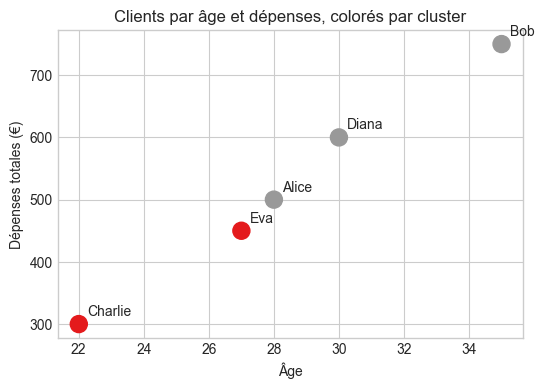

In [8]:
"""
MODULE 8 — Dashboard marketing interactif (Streamlit)
Objectif : visualisation interactive des KPIs et des segments clients.

COMMENT LANCER CE DASHBOARD :
1. Installer streamlit :  pip install streamlit plotly
2. Se placer dans le dossier du projet (celui qui contient ce fichier et le
   dossier "data/" ou "outputs/")
3. Lancer :  streamlit run M8_dashboard.py
4. Le dashboard s'ouvre automatiquement dans le navigateur (localhost:8501)

Ce script utilise les fichiers générés par M2, M3, M4 et M5. Assure-toi
d'avoir exécuté ces modules au moins une fois avant de lancer le dashboard
(sinon il recalcule tout à la volée grâce au bloc de secours ci-dessous).
"""

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import os

st.set_page_config(page_title="Dashboard Marketing IA", layout="wide")

DATA_DIR = "data"
OUT_DIR = "outputs"


@st.cache_data
def load_data():
    customers = pd.read_csv(f'{DATA_DIR}/customers_data.csv')
    sales = pd.read_csv(f'{DATA_DIR}/sales_data_.csv')
    products = pd.read_csv(f'{DATA_DIR}/products_data.csv')
    marketing = pd.read_csv(f'{DATA_DIR}/marketing_data.csv')
    sales["Revenue"] = sales["Quantity"] * sales["Sale_Price"]

    # KPIs marketing (recalcul rapide si M5 n'a pas encore tourné)
    marketing["CTR (%)"] = (marketing["Clicks"] / marketing["Impressions"] * 100).round(2)
    marketing["Taux_Conversion (%)"] = (marketing["Conversions"] / marketing["Clicks"] * 100).round(2)
    marketing["CPA (€)"] = (marketing["Budget"] / marketing["Conversions"]).round(2)
    revenu_moyen = sales["Revenue"].mean()
    marketing["ROI (%)"] = (
        (marketing["Conversions"] * revenu_moyen - marketing["Budget"]) / marketing["Budget"] * 100
    ).round(1)

    # Segments (chargés depuis outputs si M3/M4 ont tourné, sinon message)
    try:
        segmented = pd.read_csv(f"{OUT_DIR}/customers_segmented.csv")
    except FileNotFoundError:
        segmented = None

    try:
        personas = pd.read_csv(f"{OUT_DIR}/personas.csv")
    except FileNotFoundError:
        personas = None

    return customers, sales, products, marketing, segmented, personas


customers, sales, products, marketing, segmented, personas = load_data()

st.title("📊 Dashboard Marketing IA — Segmentation & Performance")
st.caption("Projet pédagogique — Analyse & Optimisation Marketing basée sur la Segmentation Client")

# ---------------------------------------------------------------------------
# KPIs globaux (cartes en haut de page)
# ---------------------------------------------------------------------------
col1, col2, col3, col4 = st.columns(4)
col1.metric("Clients", len(customers))
col2.metric("Revenu total (€)", f"{sales['Revenue'].sum():,.0f}")
col3.metric("Budget marketing total (€)", f"{marketing['Budget'].sum():,.0f}")
col4.metric("ROI moyen (%)", f"{marketing['ROI (%)'].mean():.0f}")

st.divider()

# ---------------------------------------------------------------------------
# Onglets
# ---------------------------------------------------------------------------
tab1, tab2, tab3 = st.tabs(["👥 Segmentation client", "📈 Performance campagnes", "🛒 Ventes & Produits"])

with tab1:
    st.subheader("Segments clients")
    if segmented is not None:
        cluster_filter = st.multiselect(
            "Filtrer par cluster",
            options=sorted(segmented["Cluster_KMeans"].unique()),
            default=sorted(segmented["Cluster_KMeans"].unique()),
        )
        filtered = segmented[segmented["Cluster_KMeans"].isin(cluster_filter)]
        st.dataframe(
            filtered[["Customer_ID", "Name", "Age", "Total_Spent", "Nb_Achats",
                      "Revenu_Total", "Cluster_KMeans"]],
            use_container_width=True,
        )

        if personas is not None:
            st.subheader("Personas")
            for _, p in personas.iterrows():
                with st.expander(p["Nom_persona"]):
                    st.write(f"**Clients :** {p['Clients']}")
                    st.write(p["Description"])

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.scatter(filtered["Age"], filtered["Total_Spent"],
                    c=filtered["Cluster_KMeans"], cmap="Set1", s=150)
        for _, row in filtered.iterrows():
            ax.annotate(row["Name"], (row["Age"], row["Total_Spent"]),
                        textcoords="offset points", xytext=(6, 6))
        ax.set_xlabel("Âge")
        ax.set_ylabel("Dépenses totales (€)")
        ax.set_title("Clients par âge et dépenses, colorés par cluster")
        st.pyplot(fig)
    else:
        st.warning("Lance d'abord M3_segmentation.py et M4_profilage.py pour "
                    "générer les fichiers de segmentation.")

with tab2:
    st.subheader("KPIs par campagne")
    channel_filter = st.multiselect(
        "Filtrer par canal",
        options=marketing["Channel"].unique(),
        default=list(marketing["Channel"].unique()),
    )
    filtered_mkt = marketing[marketing["Channel"].isin(channel_filter)]
    st.dataframe(
        filtered_mkt[["Campaign_ID", "Channel", "Budget", "Impressions", "Clicks",
                       "Conversions", "CTR (%)", "Taux_Conversion (%)", "CPA (€)", "ROI (%)"]],
        use_container_width=True,
    )

    col_a, col_b = st.columns(2)
    with col_a:
        st.bar_chart(filtered_mkt.set_index("Channel")["ROI (%)"])
        st.caption("ROI (%) par canal")
    with col_b:
        st.bar_chart(filtered_mkt.set_index("Channel")["CPA (€)"])
        st.caption("Coût par acquisition (€) par canal")

with tab3:
    st.subheader("Ventes et produits")
    sales_products = sales.merge(products, on="Product_ID", how="left")
    st.dataframe(sales_products, use_container_width=True)

    rev_categorie = sales_products.groupby("Category")["Revenue"].sum()
    st.bar_chart(rev_categorie)
    st.caption("Revenu total par catégorie de produit")

st.divider()
st.caption("Dashboard généré dans le cadre du Module 8 du projet pédagogique "
           "'Analyse & Optimisation Marketing basée sur la Segmentation Client'.")


SyntaxError: invalid syntax (4286492712.py, line 1)